### **Prerequisites for the Lab**

Before the session, ensure you have the environment set up.

1. Install [Ollama](https://ollama.com/) and download a lightweight model: `ollama run llama3` (or `llama3.1` or `mistral`).
2. Install the required Python libraries:

In [1]:
# Step 1: Install system compression tools and dependencies
!sudo apt-get update && sudo apt-get install -y zstd

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,094 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.5 MB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 14.0 MB in 1s (11.0 MB/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not s

In [2]:
# Step 2: Download and install the core Ollama environment binary
!curl -fsSL https://ollama.com/install.sh | sh

>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [3]:
import os, subprocess, time

os.environ['OLLAMA_HOST'] = '0.0.0.0:11434'

# Open a log file to catch the output so it doesn't fill the OS pipe
log_file = open('/content/ollama_server.log', 'w')

subprocess.Popen(
    ["ollama", "serve"],
    stdout=log_file,
    stderr=log_file
)

time.sleep(5)

In [4]:
!ollama pull llama3.1

In [5]:
!ollama pull mistral

In [6]:
!ollama pull gemma4:latest

In [7]:
!ollama pull nomic-embed-text

### 1. Environment & Telemetry Setup

Observability is non-negotiable. We configure telemetry (e.g., LangSmith or Phoenix) to trace the execution graphs.

In [8]:
!pip install langchain langgraph llama-index llama-index-llms-ollama llama-index-embeddings-ollama langchain-ollama pydantic langchain-community langchain-chroma

In [9]:
import os
import re
import sqlite3
import operator
from typing import TypedDict, Annotated, Sequence

In [10]:
from pydantic import BaseModel, Field
from langchain_core.tools import tool
from langchain_ollama import ChatOllama
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder, PromptTemplate
from langchain_classic.agents import create_tool_calling_agent, AgentExecutor
from langgraph.graph import StateGraph, END

In [ ]:
# 1. Environment & Telemetry

# Telemetry Configuration for Tracing
import os
from dotenv import load_dotenv
load_dotenv()

LANGCHAIN_API_KEY = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "Agentic_AI_Demo_Environment"

In [12]:
!ollama signin

You are already signed in as user 'usshaa'



In [13]:
# !ollama run gemma4:cloud

In [15]:
# Initialize primary LLM
primary_llm = ChatOllama(model="gemma4:latest", temperature=0)

In [16]:
from llama_index.core import SimpleDirectoryReader, VectorStoreIndex, Settings
from llama_index.embeddings.ollama import OllamaEmbedding
from llama_index.llms.ollama import Ollama

In [17]:
# 1. Configure LlamaIndex to use your local Ollama models
Settings.llm = Ollama(model="gemma4:latest", request_timeout=120.0)
Settings.embed_model = OllamaEmbedding(model_name="nomic-embed-text")

In [18]:
# 2. Ingest the documents from your directory
print("\n[SYSTEM LOG] Loading company policies from /content/company_policies...")
documents = SimpleDirectoryReader("/content/company_policies").load_data()


[SYSTEM LOG] Loading company policies from /content/company_policies...


In [19]:
# 3. Build the Vector Store Index
print("[SYSTEM LOG] Embedding documents and building Vector Index...")
policy_index = VectorStoreIndex.from_documents(documents)

[SYSTEM LOG] Embedding documents and building Vector Index...


In [20]:
# 4. Create the Query Engine interface
# policy_query_engine = policy_index.as_query_engine()
# Limit to top 2 chunks so the LLM doesn't have to process too much text
policy_query_engine = policy_index.as_query_engine(similarity_top_k=2)
print("[SYSTEM LOG] Local RAG System Ready!")

[SYSTEM LOG] Local RAG System Ready!


In [21]:
# 2. Database & Tool Definitions

# Initialize in-memory SQLite DB
conn = sqlite3.connect(':memory:', check_same_thread=False)
cursor = conn.cursor()
cursor.execute('''CREATE TABLE orders (order_id TEXT, status TEXT, delivery_date TEXT)''')
cursor.execute('''INSERT INTO orders VALUES ('ORD-12345', 'In Transit', '2026-07-08')''')
cursor.execute('''INSERT INTO orders VALUES ('ORD-67890', 'Delivered', '2026-07-01')''')
conn.commit()

In [22]:
class OrderLookupInput(BaseModel):
    order_id: str = Field(description="The exact order ID to look up. It MUST start with 'ORD-'.")

class RefundInput(BaseModel):
    order_id: str = Field(description="The exact order ID, must start with ORD-")
    reason: str = Field(description="Customer's reason for the refund request")

In [23]:
@tool("lookup_order_status", args_schema=OrderLookupInput)
def lookup_order_status(order_id: str) -> str:
    """Queries the live SQL database to retrieve shipping status and estimated delivery."""
    print(f"\n[SYSTEM LOG] Executing live SQL query for: {order_id}")
    cursor.execute("SELECT status, delivery_date FROM orders WHERE order_id = ?", (order_id,))
    result = cursor.fetchone()
    if result:
        return f"Order {order_id} is currently {result[0]}. Expected delivery: {result[1]}."
    return f"Error: Order {order_id} could not be found."

In [24]:
@tool("process_refund", args_schema=RefundInput)
def process_refund(order_id: str, reason: str) -> str:
    """Initiates a refund. Requires HITL approval."""
    return f"Refund staged for {order_id}. Awaiting supervisor gateway approval."

In [25]:
@tool
def research_policy_tool(query: str) -> str:
    """
    RAG tool for the Research Agent.
    Queries the company policy vector database to answer questions about returns, refunds, shipping, and data privacy.
    """
    print(f"\n[SYSTEM LOG] Querying Policy Vector DB for: {query}")

    # Execute the semantic search and LLM synthesis
    response = policy_query_engine.query(query)

    # Return the synthesized answer as a string back to the LangGraph Agent
    return str(response)

In [26]:
# 3. Micro-Agent Definitions

# Support Agent (CRM Tools)
support_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a Support Agent. Use your CRM tools to assist the user. ONLY answer support questions."),
    MessagesPlaceholder(variable_name="messages"),
    MessagesPlaceholder(variable_name="agent_scratchpad"),
])
support_agent = create_tool_calling_agent(primary_llm, [lookup_order_status, process_refund], support_prompt)
support_executor = AgentExecutor(
    agent=support_agent,
    tools=[lookup_order_status, process_refund],
    return_intermediate_steps=True # Add this!
)

In [27]:
# Research Agent (RAG Tool)
research_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a Research Agent specialized in company policies.
    YOUR PRIORITY: If the user says 'it', 'that', or 'the order', you MUST scan the 'messages' history to find the specific Order ID (e.g., ORD-XXXXX) referenced previously.

    1. Identify the Order ID from the chat history.
    2. Incorporate that context into your search query (e.g., 'Return policy for ORD-67890').
    3. Use the research_policy_tool to retrieve the answer.

    If you cannot find an order ID after searching history, ask the user to clarify."""),
    MessagesPlaceholder(variable_name="messages"),
    MessagesPlaceholder(variable_name="agent_scratchpad"),
])
research_agent = create_tool_calling_agent(primary_llm, [research_policy_tool], research_prompt)
research_executor = AgentExecutor(agent=research_agent, tools=[research_policy_tool])

In [28]:
# 4. LangGraph State Machine

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    next_agent: str

In [29]:
def supervisor_router(state: AgentState):
    """Evaluates user intent and routes to the correct micro-agent."""
    query = state["messages"][-1].content.lower()
    if "policy" in query or "return rules" in query:
        return {"next_agent": "ResearchTeam"}
    return {"next_agent": "SupportTeam"}

In [30]:
def support_team_node(state: AgentState):
    result = support_executor.invoke({"messages": state["messages"]})

    messages_to_add = []
    # 1. Add the hidden tool executions to the visible chat history
    for action, observation in result.get("intermediate_steps", []):
        messages_to_add.append(AIMessage(content=f"AI (Action): Called tool [{action.tool}]"))

    # 2. Add the final text response
    messages_to_add.append(AIMessage(content=result["output"]))

    return {"messages": messages_to_add}

In [31]:
def research_team_node(state: AgentState):
    result = research_executor.invoke({"messages": state["messages"]})
    return {"messages": [AIMessage(content=result["output"])]}

In [32]:
# Build the Graph
workflow = StateGraph(AgentState)
workflow.add_node("Supervisor", supervisor_router)
workflow.add_node("SupportTeam", support_team_node)
workflow.add_node("ResearchTeam", research_team_node)

In [33]:
workflow.set_entry_point("Supervisor")
workflow.add_conditional_edges(
    "Supervisor",
    lambda x: x["next_agent"],
    {"SupportTeam": "SupportTeam", "ResearchTeam": "ResearchTeam"}
)
workflow.add_edge("SupportTeam", END)
workflow.add_edge("ResearchTeam", END)

In [34]:
from langgraph.checkpoint.memory import MemorySaver

# Initialize the memory checkpointer
memory = MemorySaver()

# Recompile the graph, passing the memory object
app = workflow.compile(checkpointer=memory)
print("Graph compiled with persistent memory!")

Graph compiled with persistent memory!


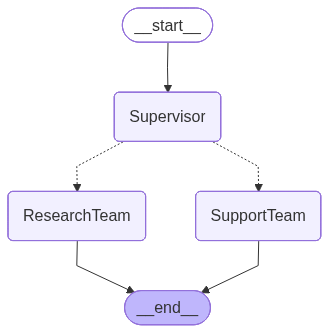

In [40]:
from IPython.display import Image, display

# Generate and display the graph visualization
display(Image(app.get_graph().draw_mermaid_png()))

In [35]:
# 5. Security Guardrails (PII Masking)

def mask_pii(text: str) -> str:
    """Scrubs emails and phone numbers before hitting the LLM."""
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '[REDACTED_EMAIL]', text)
    text = re.sub(r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b', '[REDACTED_PHONE]', text)
    return text

In [36]:
def safe_invoke_agent(user_input: str, thread_id: str = "default_user"):
    sanitized_input = mask_pii(user_input)
    print(f"\n[SECURITY] Sanitized Input: {sanitized_input}")

    # Pass the thread_id into the config!
    config = {"configurable": {"thread_id": thread_id}}
    return app.invoke({"messages": [HumanMessage(content=sanitized_input)]}, config=config)

In [37]:
# 6. LLM-as-a-Judge Evaluation Pipeline

class AgentEvaluation(BaseModel):
    goal_completed: bool = Field(description="Did the agent successfully resolve the user's core request?")
    # Update this line to be hyper-explicit for the smaller model:
    tool_accuracy: int = Field(description="Score 1-5 on whether the correct tools were used. (5 means perfect tool usage, 1 means terrible or no tool usage)")
    hallucination_detected: bool = Field(description="Did the agent invent information not in the tools?")
    feedback: str = Field(description="One sentence of constructive feedback for the agent.")

In [38]:
def evaluate_agent_session(messages: list):
    """Uses LLM-as-a-Judge with structured output."""
    # Extract exact transcript for accurate tool grading, making sure to reveal hidden tool calls!
    transcript_lines = []
    for msg in messages:
        # If the AI decided to call a tool, it lives in msg.tool_calls
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            tools_used = ", ".join([tc["name"] for tc in msg.tool_calls])
            transcript_lines.append(f"AI (Action): Called tool [{tools_used}]")

        # Capture standard text content (if any)
        if msg.content:
            transcript_lines.append(f"{msg.type.capitalize()}: {msg.content}")

    transcript = "\n".join(transcript_lines)

    judge_prompt = PromptTemplate(
        template="""You are an impartial QA auditor for a multi-agent system.
        Review the following conversation transcript and evaluate the agent's performance.
        Transcript:
        {transcript}
        """,
        input_variables=["transcript"],
    )

    # Use native structured output (bypasses PydanticOutputParser bugs)
    structured_llm = primary_llm.with_structured_output(AgentEvaluation)
    eval_chain = judge_prompt | structured_llm

    print("\n--- Running Automated Telemetry Evaluation ---")
    result = eval_chain.invoke({"transcript": transcript})

    print(f"Goal Completed: {result.goal_completed}")
    print(f"Tool Accuracy: {result.tool_accuracy}/5")
    print(f"Hallucination Detected: {result.hallucination_detected}")
    print(f"Feedback: {result.feedback}")

In [39]:
# 7. Execution Run
if __name__ == "__main__":
    # Test the pipeline by passing a specific thread_id
    final_state = safe_invoke_agent(
        "Hi, my email is john.doe@gmail.com. Can you check the status of ORD-12345?",
        thread_id="test_session_001"
    )

    print("\n--- Final Agent Response ---")
    print(final_state["messages"][-1].content)

    # Run the audit
    evaluate_agent_session(final_state["messages"])


[SECURITY] Sanitized Input: Hi, my email is [REDACTED_EMAIL]. Can you check the status of ORD-12345?

[SYSTEM LOG] Executing live SQL query for: ORD-12345

--- Final Agent Response ---
The status for order **ORD-12345** is **In Transit**. It is expected to be delivered on **July 8, 2026**.

Is there anything else I can help you with today?

--- Running Automated Telemetry Evaluation ---
Goal Completed: True
Tool Accuracy: 5/5
Hallucination Detected: False
Feedback: The agent successfully identified the user's intent (checking order status) and utilized the appropriate tool (`lookup_order_status`) to retrieve the required information. The response is clear, directly answers the query, and provides all necessary details (current status, expected delivery date). It concludes with a polite closing question, maintaining good conversational flow. This is an excellent performance demonstrating efficiency and accuracy.
